In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Opening the files

In [ ]:
# Open the file using a context manager
with np.load('tritonia_results.npz') as data:
    for key in data.files:
        print(f"Key Name: '{key}' | Data Shape: {data[key].shape} | Data Type: {data[key].dtype}")


Key Name: 'spike_i' | Data Shape: (644,) | Data Type: int32
Key Name: 'spike_t' | Data Shape: (644,) | Data Type: float64
Key Name: 'v_t' | Data Shape: (120000,) | Data Type: float64
Key Name: 'v_dsi' | Data Shape: (120000,) | Data Type: float64
Key Name: 'v_c2' | Data Shape: (120000,) | Data Type: float64
Key Name: 'v_vsi' | Data Shape: (120000,) | Data Type: float64
Key Name: 'vth_dsi' | Data Shape: (120000,) | Data Type: float64
Key Name: 'vth_c2' | Data Shape: (120000,) | Data Type: float64
Key Name: 'vth_vsi' | Data Shape: (120000,) | Data Type: float64


Voltage Trace with dynamic threshold

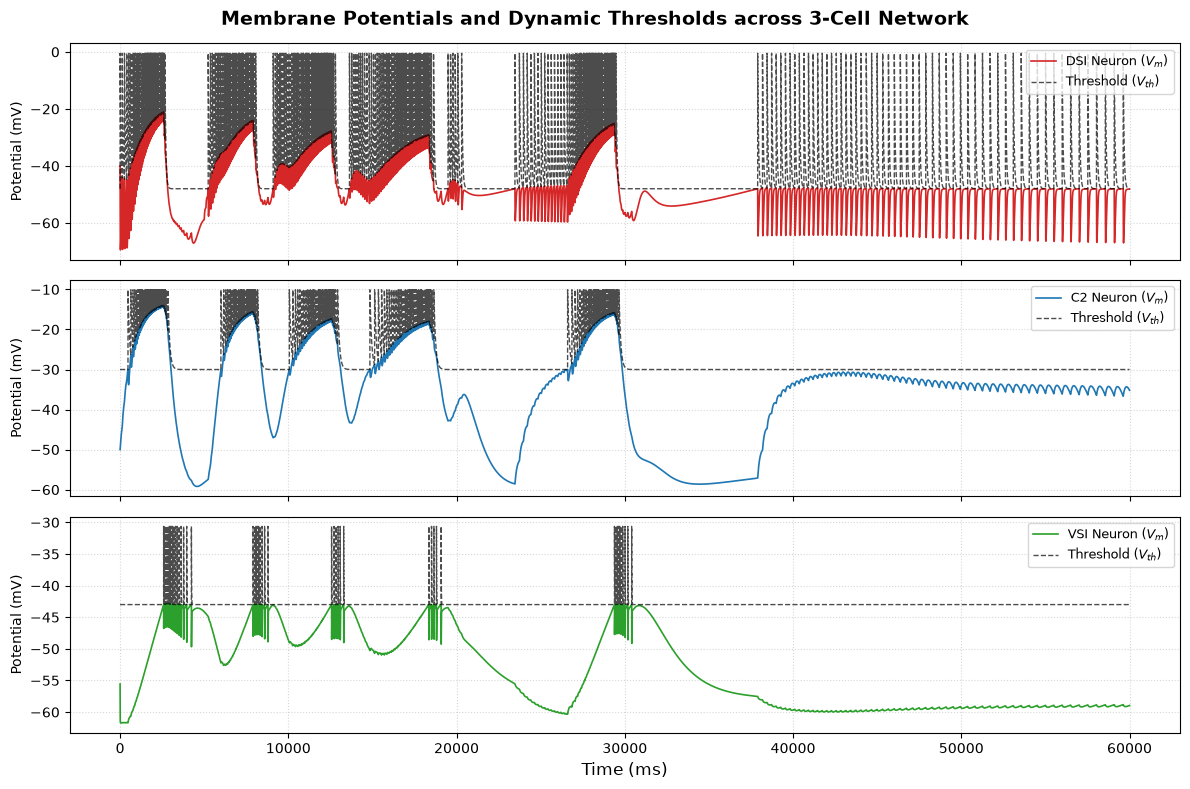

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

with np.load('tritonia_results.npz') as data:
    t = data['v_t']
    cell_data = [
        (data['v_dsi'], data['vth_dsi'], 'DSI Neuron', '#d62728'), # Red
        (data['v_c2'],  data['vth_c2'],  'C2 Neuron',  '#1f77b4'), # Blue
        (data['v_vsi'], data['vth_vsi'], 'VSI Neuron', '#2ca02c')  # Green
    ]

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, (v, vth, label, color) in enumerate(cell_data):
    axs[i].plot(t, v, color=color, linewidth=1.2, label=f'{label} ($V_m$)')
    axs[i].plot(t, vth, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Threshold ($V_{th}$)')
    axs[i].set_ylabel('Potential (mV)', fontsize=10)
    axs[i].grid(True, linestyle=':', alpha=0.5)
    axs[i].legend(loc='upper right', fontsize=9)

axs[2].set_xlabel('Time (ms)', fontsize=12)
plt.suptitle('Membrane Potentials and Dynamic Thresholds across 3-Cell Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Spikes

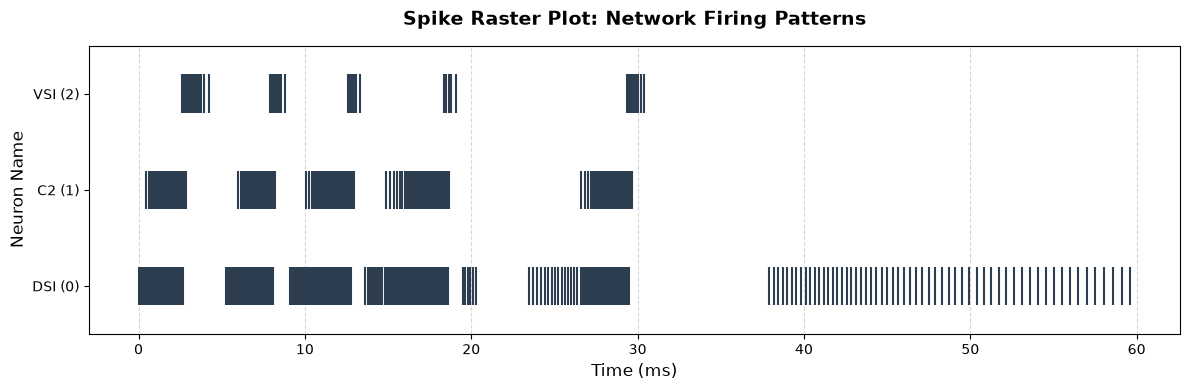

In [ ]:
with np.load('tritonia_results.npz') as data:
    spike_times = data['spike_t']
    spike_indices = data['spike_i']

plt.figure(figsize=(12, 4))
plt.vlines(spike_times, spike_indices - 0.2, spike_indices + 0.2, colors='#2c3e50', linewidth=1.5)

plt.title('Spike Raster Plot: Network Firing Patterns', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Neuron Name', fontsize=12)
plt.yticks([0, 1, 2], ['DSI (0)', 'C2 (1)', 'VSI (2)'])
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.ylim(-0.5, 2.5)
plt.tight_layout()
plt.show()
